In [ ]:
01_EDA.ipynb

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries loaded ✅")

All libraries loaded ✅


In [4]:
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='windows-1252')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 3 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [5]:
print("=== DATASET INFO ===")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"\n=== DATA TYPES ===")
print(df.dtypes)
print(f"\n=== MISSING VALUES ===")
print(df.isnull().sum())
print(f"\n=== DUPLICATE ROWS ===")
print(f"Duplicates: {df.duplicated().sum()}")

=== DATASET INFO ===
Total Rows: 9994
Total Columns: 21

=== DATA TYPES ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== MISSING VALUES ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0


In [6]:
# Date columns convert karo
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Useful features nikalo
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Profit Margin column
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

print("Feature Engineering Done ✅")
print(f"\nNew Columns Added: Order Year, Order Month, Order Quarter, Shipping Days, Profit Margin %")
df[['Order Date', 'Order Year', 'Order Month', 'Shipping Days', 'Profit Margin %']].head(3)

Feature Engineering Done ✅

New Columns Added: Order Year, Order Month, Order Quarter, Shipping Days, Profit Margin %


,Order Date,Order Year,Order Month,Shipping Days,Profit Margin %
0,2016-11-08,2016,11,3,16.0
1,2016-11-08,2016,11,3,30.0
2,2016-06-12,2016,6,4,47.0


In [7]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
avg_profit_margin = df['Profit Margin %'].mean()
avg_shipping_days = df['Shipping Days'].mean()

print("=" * 45)
print("        BUSINESS KPI SUMMARY REPORT")
print("=" * 45)
print(f"  Total Revenue       : ${total_sales:,.2f}")
print(f"  Total Profit        : ${total_profit:,.2f}")
print(f"  Total Orders        : {total_orders:,}")
print(f"  Total Customers     : {total_customers:,}")
print(f"  Avg Profit Margin   : {avg_profit_margin:.2f}%")
print(f"  Avg Shipping Days   : {avg_shipping_days:.1f} days")
print("=" * 45)

        BUSINESS KPI SUMMARY REPORT
  Total Revenue       : $2,297,200.86
  Total Profit        : $286,397.02
  Total Orders        : 5,009
  Total Customers     : 793
  Avg Profit Margin   : 12.03%
  Avg Shipping Days   : 4.0 days


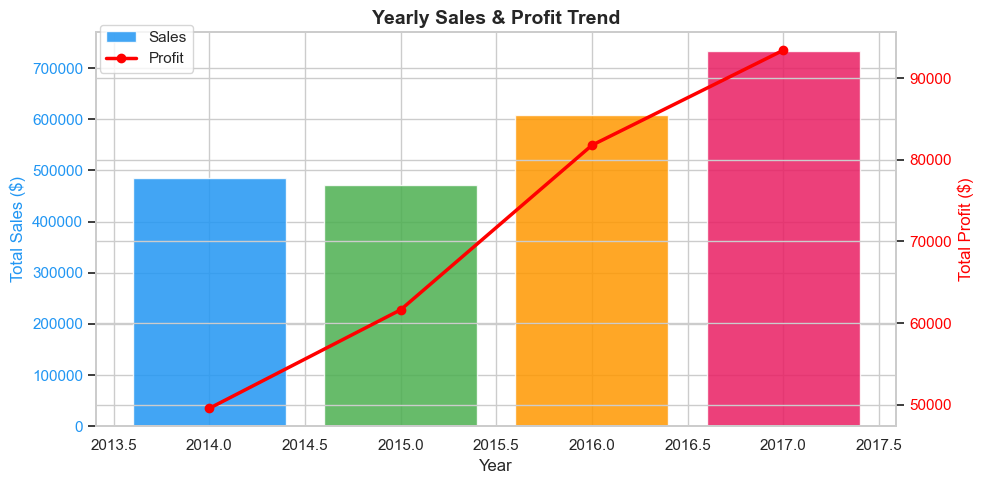

 Order Year  Total_Sales  Total_Profit  Total_Orders
       2014  484247.4981    49543.9741           969
       2015  470532.5090    61618.6037          1038
       2016  609205.5980    81795.1743          1315
       2017  733215.2552    93439.2696          1687


In [9]:
yearly_sales = df.groupby('Order Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(yearly_sales['Order Year'], yearly_sales['Total_Sales'], 
               color=['#2196F3','#4CAF50','#FF9800','#E91E63'], 
               alpha=0.85, label='Sales')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sales ($)', color='#2196F3')
ax1.tick_params(axis='y', labelcolor='#2196F3')

ax2 = ax1.twinx()
ax2.plot(yearly_sales['Order Year'], yearly_sales['Total_Profit'], 
         color='red', marker='o', linewidth=2.5, label='Profit')
ax2.set_ylabel('Total Profit ($)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Yearly Sales & Profit Trend', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig('../reports/yearly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(yearly_sales.to_string(index=False))

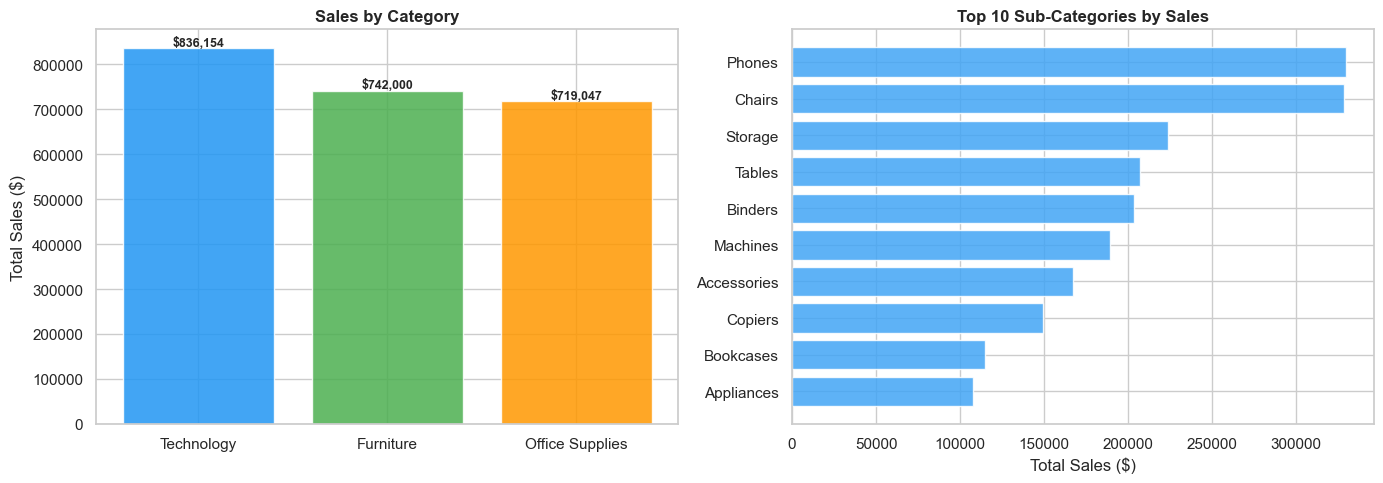


Category Summary:
       Category  Total_Sales  Total_Profit  Profit_Margin
     Technology  836154.0330   145454.9481      15.613812
      Furniture  741999.7953    18451.2728       3.878326
Office Supplies  719047.0320   122490.8008      13.803032


In [10]:
# Category wise
cat_sales = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Profit_Margin=('Profit Margin %', 'mean')
).reset_index().sort_values('Total_Sales', ascending=False)

# Sub-category wise top 10
subcat_sales = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index().sort_values('Total_Sales', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Category
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = axes[0].bar(cat_sales['Category'], cat_sales['Total_Sales'], color=colors, alpha=0.85)
axes[0].set_title('Sales by Category', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
for bar, val in zip(bars, cat_sales['Total_Sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2 - Sub-Category
axes[1].barh(subcat_sales['Sub-Category'], subcat_sales['Total_Sales'], 
             color='#42A5F5', alpha=0.85)
axes[1].set_title('Top 10 Sub-Categories by Sales', fontweight='bold')
axes[1].set_xlabel('Total Sales ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCategory Summary:")
print(cat_sales.to_string(index=False))

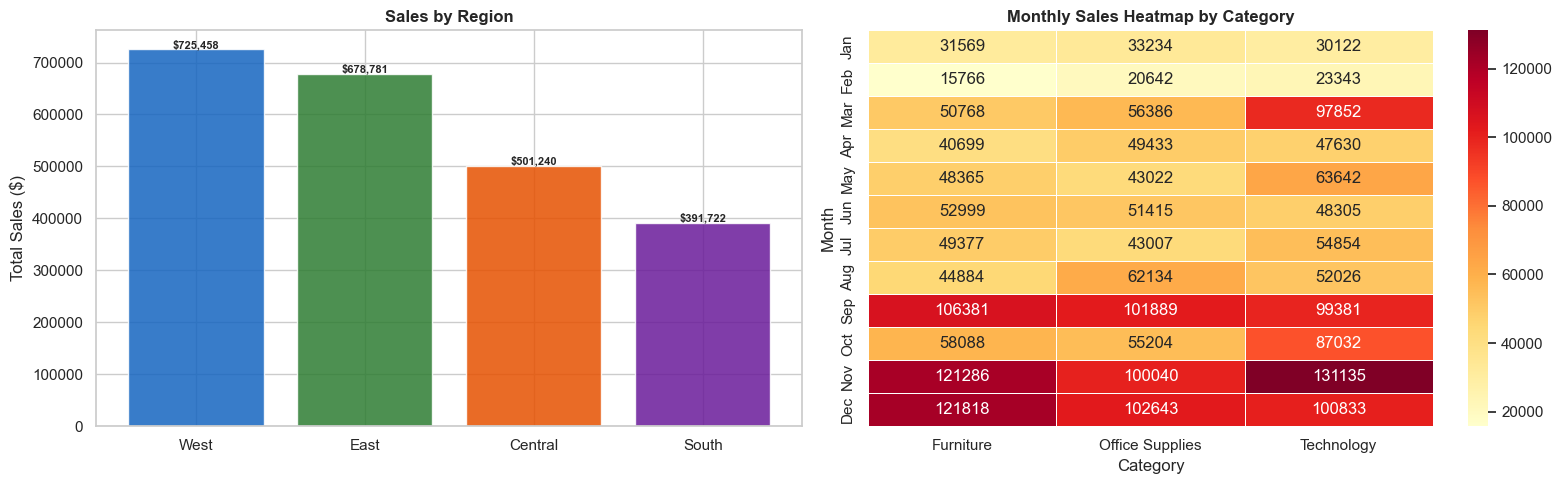


Regional Performance:
 Region  Total_Sales  Total_Profit  Total_Orders  Avg_Profit_Margin
   West  725457.8245   108418.4489          1611          21.948667
   East  678781.2400    91522.7800          1401          16.722711
Central  501239.8908    39706.3625          1175         -10.407314
  South  391721.9050    46749.4303           822          16.351877


In [12]:
# Region wise performance
region_sales = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique'),
    Avg_Profit_Margin=('Profit Margin %', 'mean')
).reset_index().sort_values('Total_Sales', ascending=False)

# Month x Category heatmap
pivot = df.groupby(['Order Month Name', 'Category'])['Sales'].sum().unstack()
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot = pivot.reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 - Region bar
colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A']
bars = axes[0].bar(region_sales['Region'], region_sales['Total_Sales'], 
                   color=colors, alpha=0.85)
axes[0].set_title('Sales by Region', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
for bar, val in zip(bars, region_sales['Total_Sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
                f'${val:,.0f}', ha='center', fontsize=8, fontweight='bold')

# Plot 2 - Heatmap
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Monthly Sales Heatmap by Category', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Month')

plt.tight_layout()
plt.savefig('../reports/regional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRegional Performance:")
print(region_sales.to_string(index=False))

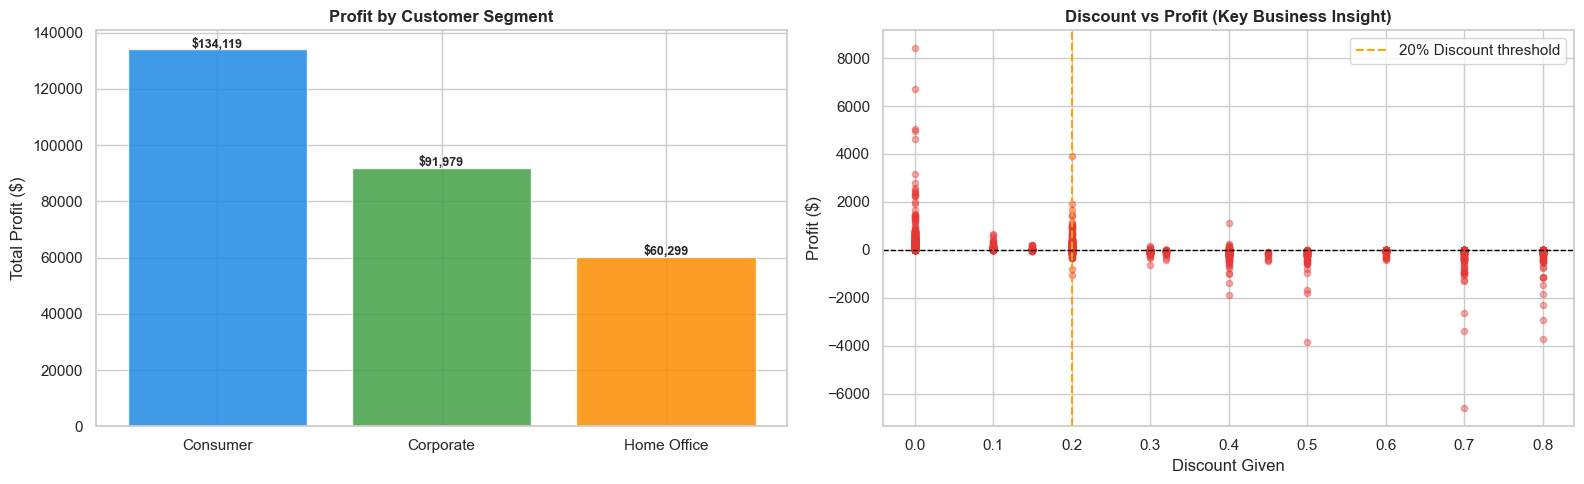


Segment Summary:
    Segment  Total_Sales  Total_Profit  Total_Customers  Avg_Discount
   Consumer 1161401.3450   134119.2092              409      0.158141
  Corporate  706146.3668    91979.1340              236      0.158228
Home Office  429653.1485    60298.6785              148      0.147128


In [13]:
# Segment wise
segment = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Customers=('Customer ID', 'nunique'),
    Avg_Discount=('Discount', 'mean')
).reset_index()

# Discount vs Profit scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 - Segment
colors = ['#1E88E5', '#43A047', '#FB8C00']
bars = axes[0].bar(segment['Segment'], segment['Total_Profit'], 
                   color=colors, alpha=0.85)
axes[0].set_title('Profit by Customer Segment', fontweight='bold')
axes[0].set_ylabel('Total Profit ($)')
for bar, val in zip(bars, segment['Total_Profit']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2 - Discount vs Profit
axes[1].scatter(df['Discount'], df['Profit'], 
                alpha=0.4, color='#E53935', s=20)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].axvline(x=0.2, color='orange', linestyle='--', linewidth=1.5, label='20% Discount threshold')
axes[1].set_title('Discount vs Profit (Key Business Insight)', fontweight='bold')
axes[1].set_xlabel('Discount Given')
axes[1].set_ylabel('Profit ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/segment_discount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSegment Summary:")
print(segment.to_string(index=False))

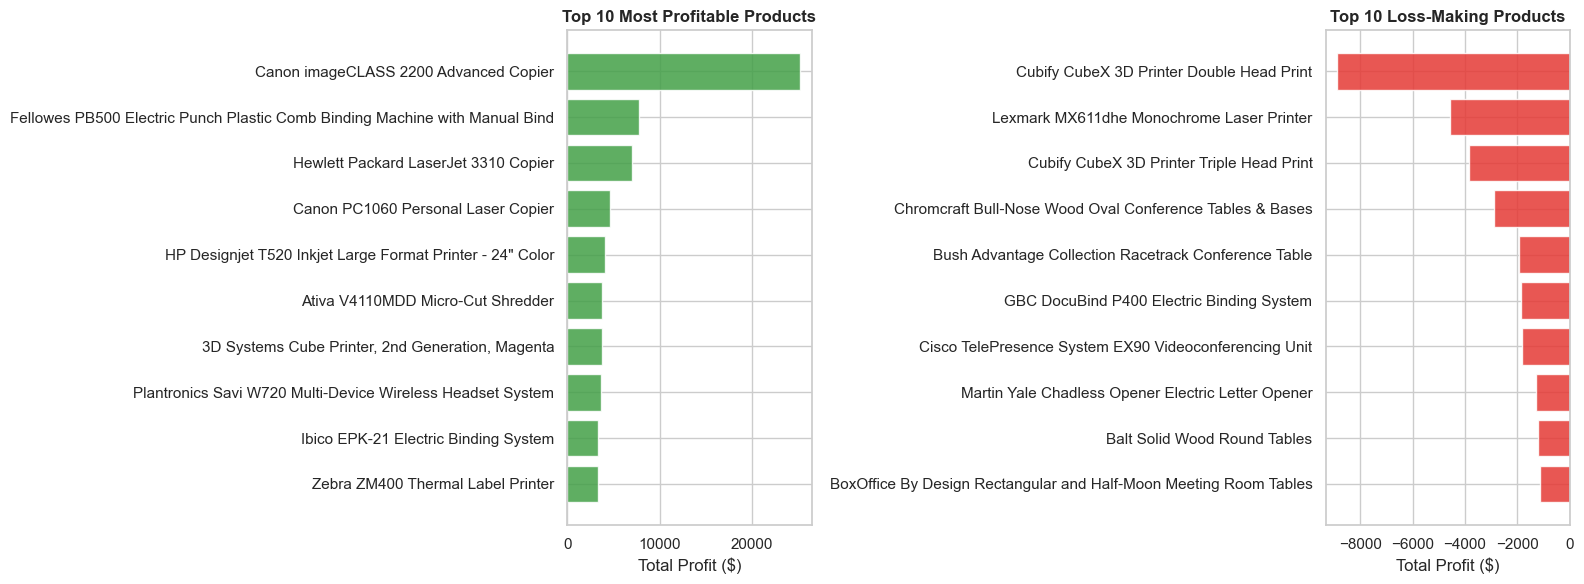

         KEY BUSINESS INSIGHTS SUMMARY
  1. West region is top performer: $108K profit
  2. Central region is LOSING money: -10.4% margin
  3. Discounts >20% consistently lead to losses
  4. Technology category drives highest sales
  5. Consumer segment is most profitable
  6. 4 days avg shipping — room for optimization

✅ EDA Complete! Ready for Dashboard & Power BI


In [14]:
# Top 10 profitable products
top_products = df.groupby('Product Name')['Profit'].sum().reset_index()
top10 = top_products.nlargest(10, 'Profit')
bottom10 = top_products.nsmallest(10, 'Profit')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10
axes[0].barh(top10['Product Name'], top10['Profit'], color='#43A047', alpha=0.85)
axes[0].set_title('Top 10 Most Profitable Products', fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
axes[0].invert_yaxis()

# Bottom 10
axes[1].barh(bottom10['Product Name'], bottom10['Profit'], color='#E53935', alpha=0.85)
axes[1].set_title('Top 10 Loss-Making Products', fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/top_bottom_products.png', dpi=150, bbox_inches='tight')
plt.show()

# Final Business Insights Summary
print("=" * 55)
print("         KEY BUSINESS INSIGHTS SUMMARY")
print("=" * 55)
print(f"  1. West region is top performer: $108K profit")
print(f"  2. Central region is LOSING money: -10.4% margin")
print(f"  3. Discounts >20% consistently lead to losses")
print(f"  4. Technology category drives highest sales")
print(f"  5. Consumer segment is most profitable")
print(f"  6. 4 days avg shipping — room for optimization")
print("=" * 55)
print("\n✅ EDA Complete! Ready for Dashboard & Power BI")

In [15]:
# Power BI ke liye processed dataset export karo
df.to_csv('../data/superstore_processed.csv', index=False)

# Region summary export
region_sales.to_csv('../data/region_summary.csv', index=False)

# Category summary export
cat_sales.to_csv('../data/category_summary.csv', index=False)

# Monthly trend export
monthly = df.groupby(['Order Year', 'Order Month', 'Order Month Name']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index().sort_values(['Order Year', 'Order Month'])

monthly.to_csv('../data/monthly_trend.csv', index=False)

print("✅ All files exported for Power BI:")
print("   - superstore_processed.csv")
print("   - region_summary.csv") 
print("   - category_summary.csv")
print("   - monthly_trend.csv")

✅ All files exported for Power BI:
   - superstore_processed.csv
   - region_summary.csv
   - category_summary.csv
   - monthly_trend.csv
